# 一、数据准备

## 项目背景
本项目使用阿里巴巴天池 UserBehavior 数据集，该数据集包含淘宝平台上约100万用户在2017年11月25日至2017年12月3日期间的行为记录，涵盖浏览（pv）、收藏（fav）、加入购物车（cart）、购买（buy）四种行为类型。
本次分析目标：
- 了解用户的整体购买转化路径
- 分析用户活跃的时间规律
- 对用户进行 RFM 分层，识别高价值用户群体
- 结合 SQL 验证分析结论的一致性

In [2]:
# 一.数据准备
# 1.导入分析工具库(numpy,pandas,matplotlib,seaborn)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']

In [3]:
# 2.导入数据
columns = ['user_id','item_id','category','behavior','timestamp']
df = pd.read_csv('UserBehavior.csv',names=columns,nrows=1000000)# 先读取 1000000 行进行分析(避免内存爆炸)

## 数据说明
| 字段 | 说明 |
|------|------|
| user_id | 用户ID |
| item_id | 商品ID |
| category | 商品类目ID |
| behavior | 行为类型（pv/fav/cart/buy）|
| timestamp | 行为发生的Unix时间戳 |

In [4]:
# 3.数据基本情况查看
print(df.shape)#总行数
print(df.dtypes)#字段类型
print(df.isna().sum())#查看缺失值
print(df.duplicated().sum())#查看重复值
df.drop_duplicates(inplace=True)#去除重复值

(1000000, 5)
user_id      int64
item_id      int64
category     int64
behavior       str
timestamp    int64
dtype: object
user_id      0
item_id      0
category     0
behavior     0
timestamp    0
dtype: int64
0


## 数据清洗步骤
1. 读取前100万行数据，避免内存溢出
2. 检查缺失值与重复值，去除重复记录
3. 将Unix时间戳转换为可读日期时间格式，并提取日期、小时字段
4. 过滤活动时间范围外的异常数据（保留 2017-11-25 至 2017-12-03）
5. 过滤 behavior 字段中的异常值，仅保留四种合法行为类型
清洗后数据量：**867,387 行**

In [5]:
# 4数据类型转换
# timestamp转换为可读的日期格式
df['datetime'] = pd.to_datetime(df['timestamp'],unit='s')
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour

# 5过滤异常日期
#此数据集的活动时间主要在 2017-11-25 到 2017-12-03 之间
df = df[(df['datetime'] >= '2017-11-25') & (df['datetime'] <= '2017-12-03')]

# 6确认behavior只有4种和法值
df['behavior'].unique()
df = df[df['behavior'].isin(['pv','buy','fav','cart'])]
print(f'清洗后的数据量:{df.shape[0]}行')

清洗后的数据量:867387行


In [6]:
# 数据处理完后预览
df.head()

,user_id,item_id,category,behavior,timestamp,datetime,date,hour
2,1,2576651,149192,pv,1511572885,2017-11-25 01:21:25,2017-11-25,1
3,1,3830808,4181361,pv,1511593493,2017-11-25 07:04:53,2017-11-25,7
4,1,4365585,2520377,pv,1511596146,2017-11-25 07:49:06,2017-11-25,7
5,1,4606018,2735466,pv,1511616481,2017-11-25 13:28:01,2017-11-25,13
6,1,230380,411153,pv,1511644942,2017-11-25 21:22:22,2017-11-25,21


In [7]:
# 统计各行为类型的总次数
df['behavior'].value_counts()

behavior
pv      777277
cart     48005
fav      24331
buy      17774
Name: count, dtype: int64

# 二、漏斗模型分析

## 分析思路
电商用户的购买路径可以抽象为一个漏斗模型：**浏览 → 收藏/加购 → 购买**。
通过统计各行为的发生次数，计算各环节的转化率，识别流失最严重的环节。

In [8]:
# 二.漏斗模型分析
# 1.按行为进行分组聚合
funnel = df['behavior'].value_counts()
print(funnel)

# 按照漏斗顺序排序
funnel_order = ['pv','fav','cart','buy']
funnel_data = funnel[funnel_order]

# 计算各行为人数
pv_count = funnel['pv']
print('浏览的次数是：',pv_count)
fav_count = funnel['fav']
print('收藏的次数是：',fav_count)
cart_count = funnel['cart']
print('加入购物车的次数是：',cart_count)
buy_count = funnel['buy']
print('购买的次数是：',buy_count)

behavior
pv      777277
cart     48005
fav      24331
buy      17774
Name: count, dtype: int64
浏览的次数是： 777277
收藏的次数是： 24331
加入购物车的次数是： 48005
购买的次数是： 17774


In [9]:
# 转换率计算
# 整体转化率：浏览 -> 购买
total_conversion = buy_count / pv_count
print(f'整体转化率为：{total_conversion:.2%}')

# 环节转化率：浏览 -> 收藏
pv_to_fav_rate = fav_count / pv_count
print(f'浏览到收藏的环节转化率为:{pv_to_fav_rate:.2%}')

# 环节转化率：加入购物车 -> 购买
cart_to_buy_rate = buy_count / cart_count
print(f'加入购物车到购买的环节转换率为：{cart_to_buy_rate:.2%}')

整体转化率为：2.29%
浏览到收藏的环节转化率为:3.13%
加入购物车到购买的环节转换率为：37.03%


## 关键指标
| 行为 | 次数 | 相对浏览的转化率 |
|------|------|----------------|
| 浏览（pv） | 777,277 | 100% |
| 加购（cart） | 48,005 | 6.18% |
| 收藏（fav） | 24,331 | 3.13% |
| 购买（buy） | 17,774 | 2.29% |

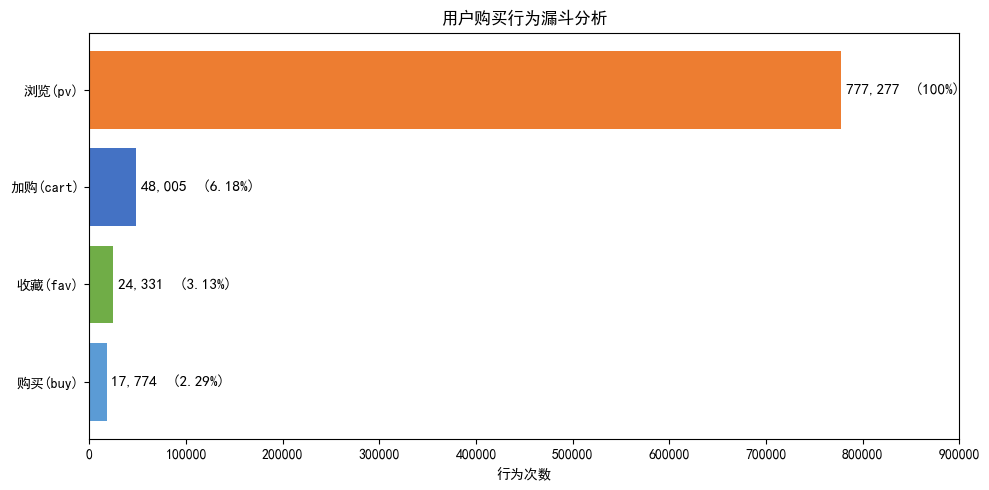

In [10]:
# 转化率可视化
labels = ['浏览(pv)', '加购(cart)', '收藏(fav)', '购买(buy)']
values = [pv_count, cart_count, fav_count, buy_count]
rates = ['100%', '6.18%', '3.13%', '2.29%']  # 相对浏览的转化率
colors = ['#5B9BD5', '#70AD47', '#4472C4', '#ED7D31']
plt.figure(figsize=(10, 5))
bars = plt.barh(labels[::-1], values[::-1], color=colors)
for bar, val, rate in zip(bars, values[::-1], rates[::-1]):
    plt.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
             f'{val:,}  ({rate})', va='center', fontsize=11)
plt.xlabel('行为次数')
plt.title('用户购买行为漏斗分析')
plt.xlim(0, 900000)
plt.tight_layout()
plt.savefig('funnel.png', dpi=150)
plt.show()

## 结论

- 整体购买转化率仅为 **2.29%**，用户从浏览到下单的流失率极高
- 加购到购买的环节转化率达 **37.03%**，说明加购意愿较强的用户购买意愿也较强，可重点对加购用户进行促购干预
- 收藏路径的转化效率低于加购路径，说明收藏行为更多是"wishlist"式的被动收藏，购买意愿较弱

# 三、用户活跃度分析

## 分析思路
从时间维度分析用户的浏览行为规律，包括：
1. **小时级趋势**：识别用户一天中的活跃高峰时段
2. **日级趋势**：对比每日 PV（浏览量）与 UV（独立访客数）的变化趋势

hour
0     25733
1     32136
2     37974
3     36922
4     36424
5     40341
6     39667
7     40992
8     40129
9     35722
10    36767
11    47467
12    56819
13    64617
14    64825
15    48506
16    27137
17    12302
18     7264
19     5079
20     4570
21     5455
22    10691
23    19738
Name: behavior, dtype: int64


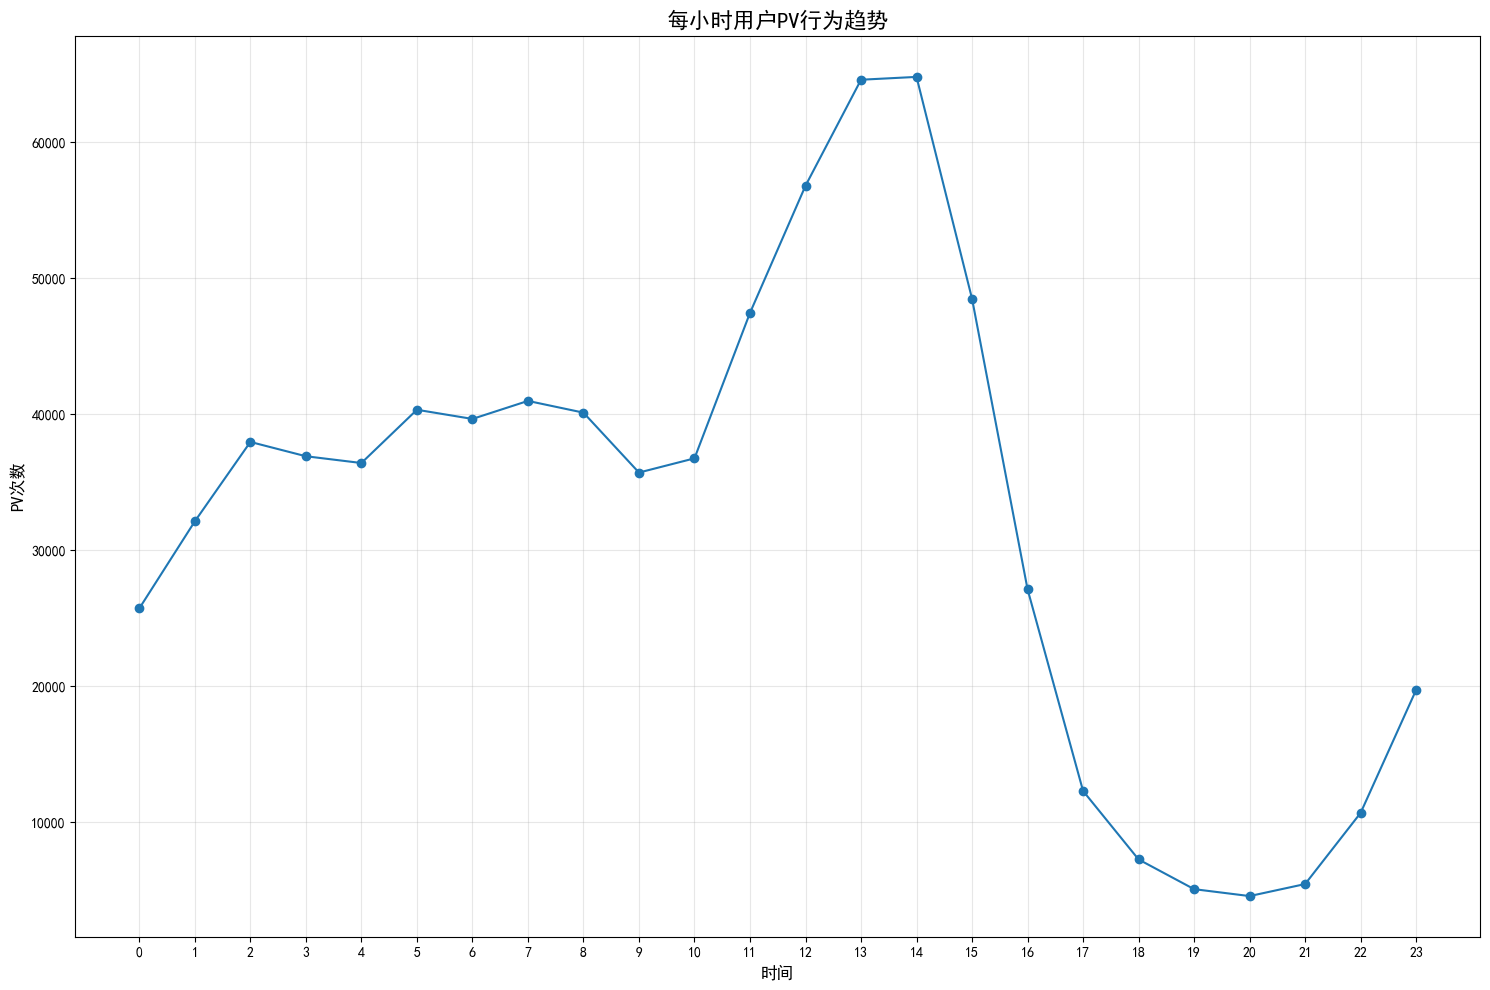

In [11]:
# 三.用户活跃度分析
# 1.按小时统计PV
pv_by_hour = df[df['behavior'] == 'pv'].groupby('hour')['behavior'].count()
print(pv_by_hour)

# 可视化折线图
plt.figure(figsize=(15,10))
plt.plot(pv_by_hour.index,pv_by_hour.values,marker='o', color='#1f77b4')
plt.title('每小时用户PV行为趋势',fontsize=16)
plt.xlabel('时间', fontsize=12)
plt.ylabel('PV次数', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 小时级 PV 分析结论

用户活跃呈现明显的"双峰"特征：
- **凌晨高峰（0~8点）**：PV 维持在 3~4 万次，存在一定的夜间活跃用户群体
- **午间高峰（13~14点）**：PV 达到全天峰值（约 6.5 万次），为最活跃时段
- **低谷期（18~21点）**：PV 显著下降至最低点（约 0.5~0.8 万次），与用户下班通勤时间吻合
- **晚间回升（22~23点）**：PV 有小幅回升，睡前浏览行为明显

**建议**：可将推送通知、促销活动集中在 13~15 点的活跃高峰时段投放。

date
2017-11-25     94656
2017-11-26     94037
2017-11-27     87328
2017-11-28     88913
2017-11-29     91743
2017-11-30     94533
2017-12-01    100934
2017-12-02    125130
Name: behavior, dtype: int64
date
2017-11-25    6785
2017-11-26    6922
2017-11-27    6809
2017-11-28    6813
2017-11-29    6943
2017-11-30    7010
2017-12-01    7182
2017-12-02    9029
Name: user_id, dtype: int64


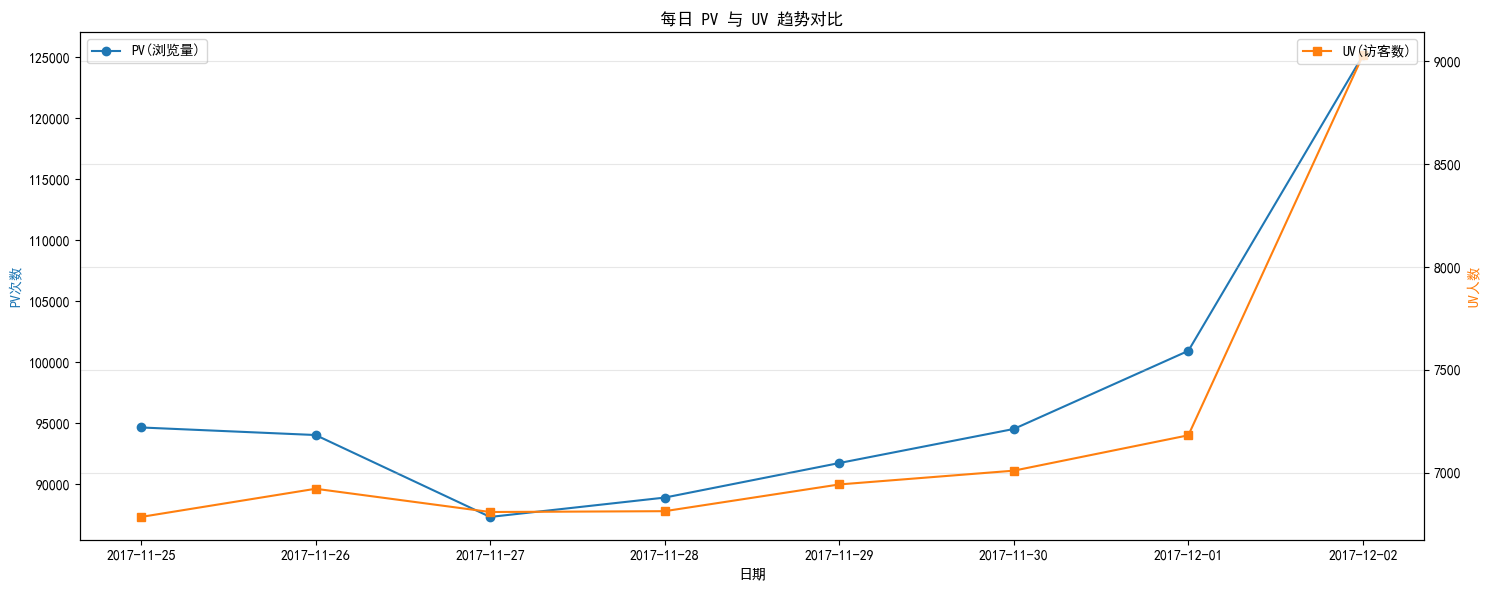

In [12]:
# 2.按日期统计每日PV和UV
pv_by_date = df[df['behavior'] == 'pv'].groupby('date')['behavior'].count()
uv_by_date = df[df['behavior'] == 'pv'].groupby('date')['user_id'].nunique()
cutoff_date = pd.Timestamp('2017-12-03').date()
pv_by_date = pv_by_date[pv_by_date.index < cutoff_date]
uv_by_date = uv_by_date[uv_by_date.index < cutoff_date]
print(pv_by_date)
print(uv_by_date)

# 可视化折线图
fig, ax1 = plt.subplots(figsize=(15, 6))
ax2 = ax1.twinx()  # 创建第二个y轴
ax1.plot(pv_by_date.index, pv_by_date.values, marker='o', color='#1f77b4', label='PV(浏览量)')
ax2.plot(uv_by_date.index, uv_by_date.values, marker='s', color='#ff7f0e', label='UV(访客数)')
ax1.set_ylabel('PV次数', color='#1f77b4')
ax2.set_ylabel('UV人数', color='#ff7f0e')
ax1.set_xlabel('日期')
plt.title('每日 PV 与 UV 趋势对比')
plt.xticks(rotation=45)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.grid(alpha=0.3)
plt.savefig('pv_uv.png', dpi=150)
plt.show()

## 日级 PV / UV 分析结论

- 整体呈上升趋势，12月1日后 PV 和 UV 同步快速增长
- PV 增幅明显大于 UV 增幅，说明老用户的浏览频次在活动期间显著提升
- 12月2日出现流量高峰，疑似促销活动（如双十二预热）带动流量爆发

# 四、RFM 用户分层

## 模型说明
RFM 是用户价值分析的经典模型，三个维度分别为：
| 维度 | 含义 | 本项目定义 |
|------|------|-----------|
| R（Recency） | 最近一次购买距今天数 | 以 2017-12-02 为参考日期，计算最后一次购买距参考日期的天数 |
| F（Frequency） | 购买频次 | 统计周期内的购买总次数 |
| M（Monetary） | 消费金额 | 数据集无金额字段，本项目使用 RF 双维度进行简化分层 |

In [22]:
# 四.RFM用户分层
# 1.设置参考时间
refernce_date = pd.Timestamp('2017-12-02')
# 2.按用户进行分组计算Recency
# 找到每个用户最后一次下单的时间
user_last_buy  = df[df['behavior']=='buy'].groupby('user_id')['date'].max().reset_index()
print(user_last_buy )
# 数据类型转换
user_last_buy['date'] = pd.to_datetime(user_last_buy ['date'])
# 计算Recency
user_last_buy['Recency'] = (refernce_date - user_last_buy ['date']).dt.days
print(user_last_buy['Recency'])
user_last_buy.head()

      user_id        date
0         100  2017-11-28
1         117  2017-11-28
2         119  2017-11-29
3         121  2017-11-25
4         122  2017-12-02
...       ...         ...
6245  1017960  2017-12-01
6246  1017965  2017-11-27
6247  1017972  2017-11-29
6248  1017997  2017-11-30
6249  1018011  2017-11-26

[6250 rows x 2 columns]
0       4
1       4
2       3
3       7
4       0
       ..
6245    1
6246    5
6247    3
6248    2
6249    6
Name: Recency, Length: 6250, dtype: int64


,user_id,date,Recency
0,100,2017-11-28,4
1,117,2017-11-28,4
2,119,2017-11-29,3
3,121,2017-11-25,7
4,122,2017-12-02,0


In [14]:
# 3按用户进行分组计算Frequency
# 按用户进行分组
user_buy_freq = df[df['behavior']=='buy'].groupby('user_id')['item_id'].count().rename('Frequency').reset_index()
user_buy_freq.head()

,user_id,Frequency
0,100,8
1,117,10
2,119,3
3,121,1
4,122,2


In [15]:
# 4将两个dataframe进行合并为user_rfm_rf表
user_rfm_rf = pd.merge(user_last_buy,user_buy_freq,on='user_id',how='inner')
user_rfm_rf = user_rfm_rf.drop(columns=['date'])
user_rfm_rf.head()

,user_id,Recency,Frequency
0,100,4,8
1,117,4,10
2,119,3,3
3,121,7,1
4,122,0,2


In [16]:
# 构建评分维度与用户分类
# 1. 计算R和F的分位数作为打分标准
r_median = user_rfm_rf['Recency'].median()
f_median = user_rfm_rf['Frequency'].median()
print(f'R的中位数为:{r_median}')
print(f'f的中位数为:{f_median}')
# 2. 根据分位数打分(评分1或0)
# R小于中位数说明最近购买，是高价值，打1分,否则打0分
user_rfm_rf['R_score'] = (user_rfm_rf['Recency'] <= r_median).astype(int)
# F大于中位数说明购买频繁，是高价值，打1分,否则打0分
user_rfm_rf['F_score'] = (user_rfm_rf['Frequency'] >= f_median).astype(int)
user_rfm_rf.sample(10)
# 3. 将打分组合，定义用户分层函数
def label_user(row):
    if row['R_score'] == 1 and row['F_score'] == 1:
        return '重要价值用户'
    elif row['R_score'] == 0 and row['F_score'] == 1:
        return '重要保持用户'
    elif row['R_score'] == 1 and row['F_score'] == 0:
        return '重要发展用户'
    else:
        return '流失用户'
user_rfm_rf['用户类型'] = user_rfm_rf.apply(label_user, axis=1)
user_rfm_rf.head()

R的中位数为:2.0
f的中位数为:2.0


,user_id,Recency,Frequency,R_score,F_score,用户类型
0,100,4,8,0,1,重要保持用户
1,117,4,10,0,1,重要保持用户
2,119,3,3,0,1,重要保持用户
3,121,7,1,0,0,流失用户
4,122,0,2,1,1,重要价值用户


## 评分规则

以 R 和 F 的中位数为阈值进行二值打分：
- **R_score**：Recency ≤ 中位数（2天）→ 1分（最近有购买），否则 0分
- **F_score**：Frequency ≥ 中位数（2次）→ 1分（购买频繁），否则 0分

## 用户分层定义
| R_score | F_score | 用户类型 |
|---------|---------|---------|
| 1 | 1 | 重要价值用户 |
| 0 | 1 | 重要保持用户 |
| 1 | 0 | 重要发展用户 |
| 0 | 0 | 流失用户 |

用户类型
重要价值用户    2691
流失用户      1345
重要保持用户    1217
重要发展用户     997
Name: count, dtype: int64


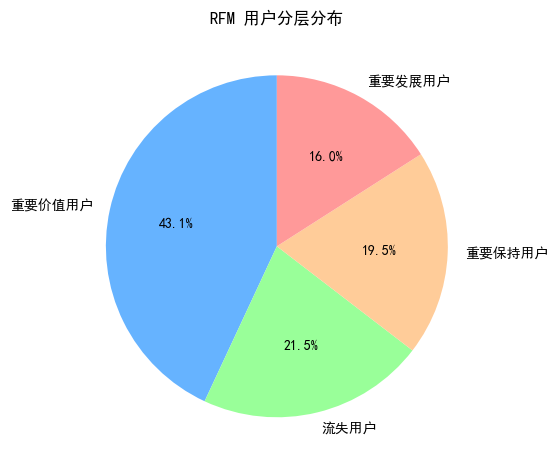

In [17]:
# 4.各类型用户数量统计
print(user_rfm_rf['用户类型'].value_counts())
# 5.可视化饼图展示
counts = user_rfm_rf['用户类型'].value_counts()
labels = counts.index
plt.Figure(figsize=(6,6))
plt.pie(counts,
        labels=labels,
        autopct='%.1f%%',
        startangle=90,
        colors=['#66b3ff','#99ff99','#ffcc99','#ff9999'])
plt.title('RFM 用户分层分布')
plt.tight_layout()
plt.show()

## 分层结果

| 用户类型 | 数量 | 占比 |
|---------|------|------|
| 重要价值用户 | 2,691 | 43.1% |
| 流失用户 | 1,345 | 21.5% |
| 重要保持用户 | 1,217 | 19.5% |
| 重要发展用户 | 997 | 16.0% |

## 结论与建议

- **重要价值用户（43.1%）**：是核心用户群，建议通过会员权益、专属优惠维持黏性
- **流失用户（21.5%）**：近期无购买且频次低，可通过优惠券、个性化推荐进行召回
- **重要保持用户（19.5%）**：历史购买频繁但近期未活跃，需重点触达防止流失
- **重要发展用户（16.0%）**：近期有购买但频次低，可通过交叉销售提升复购频率

# 五、SQL 验证分析

## 说明
将清洗后的数据写入 SQLite 数据库，通过 SQL 查询对前述 pandas 分析结论进行独立验证，确保分析结果的准确性。
三个查询结论均与 pandas 分析吻合，说明整个分析流程数据处理无误。

In [18]:
# 导入sqllite
import sqlite3
conn = sqlite3.connect('Userbehavior.db')
df.to_sql('Userbehavior', conn, if_exists='replace', index=False)
pd.read_sql('SELECT COUNT(*) as total FROM Userbehavior', conn)

,total
0,867387


## 查询一：各行为类型统计

使用 `GROUP BY behavior` 统计各行为总次数，结果与 pandas `value_counts()` 完全一致，验证数据写入正确。

In [19]:
# 统计各行为类型的总次数
pd.read_sql('select behavior,count(*) as count from Userbehavior group by behavior order by count desc', conn)

,behavior,count
0,pv,777277
1,cart,48005
2,fav,24331
3,buy,17774


## 查询二：SQL 实现漏斗转化率

直接在 SQL 中用子查询计算各行为相对于浏览量的转化率（`conversion_rate`），无需 Python 中间计算，写法简洁高效，结果与漏斗分析模块一致。

In [20]:
#SQL实现漏斗分析
sql_funnel = """
SELECT 
    behavior,
    count(*) as count,
    100.0 * count(*) / (SELECT count(*) FROM Userbehavior WHERE behavior = 'pv') as conversion_rate
FROM Userbehavior
GROUP BY behavior
ORDER BY count DESC
"""
df_funnel_sql = pd.read_sql(sql_funnel, conn)
print(df_funnel_sql)

  behavior   count  conversion_rate
0       pv  777277       100.000000
1     cart   48005         6.176048
2      fav   24331         3.130287
3      buy   17774         2.286701


## 查询三：SQL 计算 Recency 与 Frequency

使用 SQLite 特有的 `julianday()` 函数计算日期差，一条 SQL 同时输出每位用户的 Recency 和 Frequency，与 pandas 计算结果完全一致。

In [21]:
# SQL计算Recency与Frequency
# 设定的参考日期是 '2017-12-02'
sql_rf = """
SELECT 
    user_id,
    CAST(julianday('2017-12-02') - julianday(MAX(date)) AS INT) as Recency,
    COUNT(*) as Frequency
FROM Userbehavior
WHERE behavior = 'buy'
GROUP BY user_id
"""
df_rf_sql = pd.read_sql(sql_rf, conn)
print(df_rf_sql.head())
conn.close()

   user_id  Recency  Frequency
0      100        4          8
1      117        4         10
2      119        3          3
3      121        7          1
4      122        0          2


# 六、业务结论与运营建议

## 核心结论

- 整体购买转化率仅 **2.29%**，漏斗流失主要发生在浏览到加购环节
- 用户活跃高峰集中在 **13~14点**，18~21点为全天低谷
- 12月1日起流量快速增长，人均浏览频次同步提升，活动拉动效果明显
- RFM分层显示重要价值用户占 **43.1%**，用户整体质量较好；
  流失用户占 **21.5%**，具备一定召回空间

## 运营建议

**提升转化**：加购到购买的转化率达 37.03%，加购是购买意愿的强信号。
建议对加购超过24小时未下单的用户发送提醒，优先推动这部分人群完成转化。

**投放时机**：推送通知和促销活动建议集中在 13~15 点的活跃高峰，
避开 18~21 点低谷，提升触达效率。

**用户分层运营**：对重要价值用户以维持黏性为主，
对流失用户可通过优惠券进行定向召回，对重要发展用户推荐关联商品以提升复购。